# ViT-Tiny

Implementation of a tiny version of the Vision Transformer for image classification on CIFAR-10.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import os

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "DATA"))
CKPT_DIR = './checkpoints/3_ViT'
os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device = {device}")

device = cuda


---
# 0. Dataset

CIFAR-10 : 60k color images of size 32×32 split into 50k training samples and 10k test samples, distributed across 10 classes : airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. 

In [4]:
BATCH_SIZE = 128
IMG_SIZE   = 32
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_tf)
test_set  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_img, _ = train_set[0]
CHANNELS, H, W = sample_img.shape
NUM_CLASSES    = len(train_set.classes)
print(f"train {len(train_set)} | test {len(test_set)}")
print(f"Num classes : {NUM_CLASSES}  {train_set.classes}")

19.1%


KeyboardInterrupt: 

---
# 1. Patch Embedding

Starting from a batch of images $X \in \mathbb{R}^{B \times C \times H \times W}$, we build $z_0 \in \mathbb{R}^{B \times T \times d_{\text{model}}}$ in 4 steps.


**Step 1 : Split into patches**

Each image is divided into $n_{\text{patches}} = \text{grid\_size} \times \text{grid\_size}$ non-overlapping patches of size $\text{patch\_size} \times \text{patch\_size}$, where $\text{grid\_size} = \dfrac{H}{\text{patch\_size}}$.
Each patch is then flattened into a vector of $\text{patch\_dim} = \text{patch\_size}^2 \cdot C$ values.

$$X \in \mathbb{R}^{B \times C \times H \times W} \;\longrightarrow\; X_p \in \mathbb{R}^{B \times n_{\text{patches}} \times \text{patch\_dim}}$$

For CIFAR-10 with $\text{patch\_size} = 4$ : $n_{\text{patches}} = 8 \times 8 = 64$ patches, $\text{patch\_dim} = 48$ values per patch.


**Step 2 : Linear projection**

Each patch is projected from raw pixel space to the model dimension $d_{\text{model}}$ using a learnable matrix $E \in \mathbb{R}^{\text{patch\_dim} \times d_{\text{model}}}$.

$$X_p \in \mathbb{R}^{B \times n_{\text{patches}} \times \text{patch\_dim}} \;\longrightarrow\; X_p E \in \mathbb{R}^{B \times n_{\text{patches}} \times d_{\text{model}}}$$


**Step 3 : Prepend CLS token**

A learnable vector $x_{\text{class}} \in \mathbb{R}^{d_{\text{model}}}$ is prepended to the sequence as row 0.
It will aggregate global information about the image through the attention layers.

$$\mathbb{R}^{B \times n_{\text{patches}} \times d_{\text{model}}} \;\longrightarrow\; \mathbb{R}^{B \times (n_{\text{patches}} + 1) \times d_{\text{model}}} = \mathbb{R}^{B \times T \times d_{\text{model}}}$$

with $T = n_{\text{patches}} + 1$.


**Step 4 : Add positional embeddings**

A learnable matrix $E_{\text{pos}} \in \mathbb{R}^{T \times d_{\text{model}}}$ is added to the sequence.
It encodes the position of each token, since self-attention is permutation-invariant.

$$z_0 = \begin{bmatrix} x_{\text{class}} \\ x_p^1 E \\ x_p^2 E \\ \vdots \\ x_p^{n_{\text{patches}}} E \end{bmatrix} + E_{\text{pos}} \quad \in \mathbb{R}^{B \times T \times d_{\text{model}}}$$

where :

$x_{\text{class}} \in \mathbb{R}^{d_{\text{model}}}$ : learnable CLS token

$x_p^i \in \mathbb{R}^{\text{patch\_dim}}$ : flattened patch $i$

$E \in \mathbb{R}^{\text{patch\_dim} \times d_{\text{model}}}$ : learnable projection matrix (`nn.Linear(patch_dim, d_model)`)

$E_{\text{pos}} \in \mathbb{R}^{T \times d_{\text{model}}}$ : learnable positional embeddings

For CIFAR-10 : $z_0 \in \mathbb{R}^{B \times 65 \times 128}$.

Each Transformer block applies :

$$z'_\ell = \text{MSA}(\text{LN}(z_{\ell-1})) + z_{\ell-1}$$

$$z_\ell = \text{MLP}(\text{LN}(z'_\ell)) + z'_\ell$$

where :

$\text{LN}$ : LayerNorm

$\text{MSA}$ : Multi-Head Self-Attention with `num_heads` heads

$\text{MLP}$ : 2-layer feed-forward network ($d_{\text{model}} \to d_{\text{ff}} \to d_{\text{model}}$) with GELU activation

## Hyperparameters

In [3]:
PATCH_SIZE  = 4
GRID_SIZE   = IMG_SIZE // PATCH_SIZE #8
N_PATCHES   = GRID_SIZE ** 2 #64
PATCH_DIM   = PATCH_SIZE ** 2 * CHANNELS #48

D_MODEL    = 128
NUM_HEADS  = 4
NUM_LAYERS = 6
D_FF       = 4 * D_MODEL
DROPOUT    = 0.1

NUM_EPOCHS = 60

In [4]:
def patchify(images, patch_size): #images(B,C,H,W)
    B, C, H, W = images.shape  
    P = patch_size
    x = images.reshape(B, C, H // P, P, W // P, P)
    x = x.permute(0, 2, 4, 3, 5, 1)
    x = x.reshape(B, (H // P) * (W // P), P * P * C)
    return x #x(B,N,patch_size)

In [5]:
class ViTEncoder(nn.Module):
    
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, channels=CHANNELS,d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,d_ff=D_FF, dropout=DROPOUT):
        super().__init__()
        n_patches = (img_size // patch_size) ** 2 #64
        patch_dim = patch_size ** 2 * channels #48
        self.patch_size = patch_size

        self.projection    = nn.Linear(patch_dim, d_model)
        self.cls_token     = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embedding = nn.Parameter(torch.randn(1, n_patches + 1, d_model) * 0.02)
        self.dropout       = nn.Dropout(dropout)

        block = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=d_ff,dropout=dropout, activation='gelu', batch_first=True, norm_first=True,bias=True)
        self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, images):
        B = images.shape[0] #128
        x = patchify(images, self.patch_size) #x(B,N,patch_size)
        x = self.projection(x) #x(B,N,d_model)
        cls = self.cls_token.expand(B, -1, -1) #(B,1,d_model)
        x = torch.cat([cls, x], dim=1) + self.pos_embedding #x(B,N+1,d_model)
        x = self.dropout(x) #x(B,N+1,d_model)
        x = self.transformer(x) #x(B,N+1,d_model)
        x = self.norm(x) ##x(B,N+1,d_model) apply LayerNorm
        return x[:, 0, :] ##x(B,d_model) CLS token

---
# 2. Classifier

We extract the CLS token from the final Transformer output $z_L$ and pass it through a single linear layer to produce class logits :

$$\text{logits} = z_L^{\text{[CLS]}}\, W_{\text{head}}^T + b_{\text{head}} \in \mathbb{R}^{B \times \text{num\_classes}}$$

with $W_{\text{head}} \in \mathbb{R}^{\text{num\_classes} \times d_{\text{model}}}$ and $b_{\text{head}} \in \mathbb{R}^{\text{num\_classes}}$.

In [6]:
class ViTClassifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(D_MODEL, num_classes)
    def forward(self, x): #x(B,C,H,W)
        return self.head(self.encoder(x)) #logits(B,10)


encoder = ViTEncoder().to(device)
model   = ViTClassifier(encoder, NUM_CLASSES).to(device)

params = sum(p.numel() for p in model.parameters())

patch_proj   = PATCH_DIM * D_MODEL + D_MODEL     
   
cls_token    = D_MODEL                              
pos_embed    = (N_PATCHES + 1) * D_MODEL            

attn         = 4 * D_MODEL * D_MODEL + 4 * D_MODEL
ffn          = 2 * D_MODEL * D_FF + D_FF + D_MODEL  
layer_norms  = 2 * (2 * D_MODEL)                      
per_block    = attn + ffn + layer_norms
all_blocks   = NUM_LAYERS * per_block

final_norm   = 2 * D_MODEL                            
head         = D_MODEL * NUM_CLASSES + NUM_CLASSES   

params_th = patch_proj + cls_token + pos_embed + all_blocks + final_norm + head

print(f"empirical : {params:,}")
print(f"theory    : {params_th:,}")
print(f"match     : {params == params_th}")

C:\Users\hugop\AppData\Local\Temp\ipykernel_33184\3349593565.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)


empirical : 1,205,898
theory    : 1,205,898
match     : True


---
# 3. Training

In [7]:
def slope_per_epoch(values, window=5):
    if len(values) < 2:
        return float('inf')
    w = min(window, len(values))
    y = np.array(values[-w:]); x = np.arange(w)
    return float(np.polyfit(x, y, 1)[0])

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc);   test_accs.append(te_acc)
    print(f"epoch {epoch:2d}/{NUM_EPOCHS} | train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'train_losses': train_losses, 'test_losses': test_losses,
                    'train_accs':   train_accs,   'test_accs':   test_accs},
                   os.path.join(CKPT_DIR, 'vit_best.pt'))

    best_epoch = test_accs.index(max(test_accs))
    if (len(test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print(f"\nbest test acc : {max(test_accs)*100:.2f}%")
print(f"converged at  : epoch {test_accs.index(max(test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in test_accs]):.3f} %/epoch")

epoch  1/60 | train 1.8313 31.0% | test 1.6942 38.1%
epoch  2/60 | train 1.5506 43.2% | test 1.4498 47.2%
epoch  3/60 | train 1.4200 48.0% | test 1.3028 52.3%
epoch  4/60 | train 1.3425 51.2% | test 1.2303 55.5%
epoch  5/60 | train 1.2800 53.6% | test 1.1720 57.6%
epoch  6/60 | train 1.2285 55.6% | test 1.1538 57.9%
epoch  7/60 | train 1.1894 57.0% | test 1.1089 60.0%
epoch  8/60 | train 1.1396 58.9% | test 1.0309 62.9%
epoch  9/60 | train 1.1011 60.5% | test 1.0541 62.2%
epoch 10/60 | train 1.0643 61.7% | test 1.0020 63.9%
epoch 11/60 | train 1.0249 63.3% | test 0.9935 64.4%
epoch 12/60 | train 0.9932 64.5% | test 0.9746 65.7%
epoch 13/60 | train 0.9681 65.4% | test 0.8831 67.8%
epoch 14/60 | train 0.9333 66.6% | test 0.9035 67.8%
epoch 15/60 | train 0.9112 67.4% | test 0.8789 69.3%
epoch 16/60 | train 0.8861 68.6% | test 0.8929 68.8%
epoch 17/60 | train 0.8699 69.0% | test 0.8343 70.6%
epoch 18/60 | train 0.8437 70.1% | test 0.8218 71.3%
epoch 19/60 | train 0.8239 70.8% | test 0.8121

## Curves

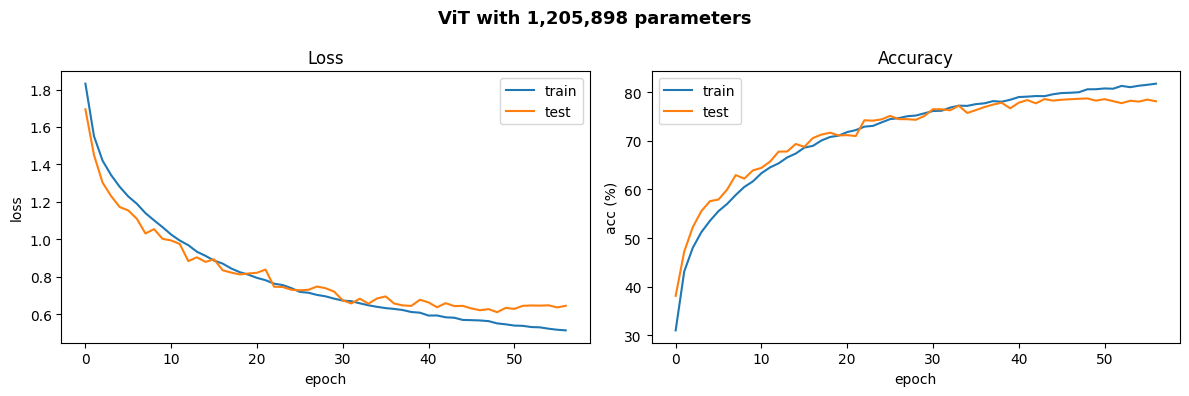

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='train'); ax1.plot(test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in train_accs], label='train'); ax2.plot([a*100 for a in test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'ViT with {params:,} parameters', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
# 4. Results
Plot 10 random predictions from the test set 

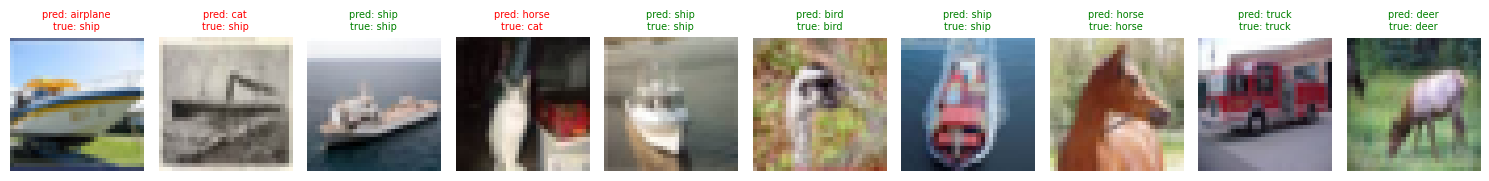

In [10]:
def unnorm(img):
    m = torch.tensor(MEAN).view(3, 1, 1)
    s = torch.tensor(STD).view(3, 1, 1)
    return (img * s + m).clamp(0, 1)

model.eval()
indices = torch.randint(0, len(test_set), (10,))
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_set[idx]
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()
    axes[i].imshow(unnorm(img).permute(1, 2, 0).numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {test_set.classes[pred]}\ntrue: {test_set.classes[true_label]}",
                       fontsize=7, color=color)
    axes[i].axis('off')
plt.tight_layout()
plt.show()